In [ ]:
"""
Created on 09/04/2026
Apply  Catboost (PCA and IQR applied log rtansformed feature)

Input: IR Spectroscopy Data  (old dataset) + Leverage Method (No IQR)

@author: Mehryar Jafari

"""

'\nCreated on 09/04/2026\nApply  Catboost (PCA and IQR applied log rtansformed feature)\n\nInput: IR Spectroscopy Data  (old dataset) + Leverage Method (No IQR)\n\n@author: Mehryar Jafari\n\n'

In [1]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


In [3]:

# Importing Necessary Libraries

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from random import shuffle
import os
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from joblib import dump
import re
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
import joblib
import seaborn as sns
from collections import Counter
import json
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [4]:
graphid = []
CO2 = {}
N2 = {}
O2 = {}
CH4 = {}
H2 = {}
He = {}
data_He  = {}
data_H2  = {}
data_N2  = {}
data_O2  = {}
data_CH4 = {}
data_CO2 = {}
classification = {}
xdata = []
ydata_reg = []
ydata_clf = []
unik = []

In [7]:

# --- Load data

meta = pd.read_csv('Polymer_Dataset_Refined_Categories_Encoded_No_Unknown.csv') # Load all columns from the new dataset

# graphs.csv: col0 = new_key, col1 = ItemNumber (to match meta)
graphs_df = pd.read_csv('graphs.csv', header=None, usecols=[0,1], names=['new_key','Item'])

# --- Ensure integer keys for a clean join
meta['Item']     = meta['Item'].astype(int)
graphs_df['Item'] = graphs_df['Item'].astype(int)
graphs_df['new_key']    = graphs_df['new_key'].astype(int)

# --- Keep only items present in BOTH (inner join)
merged = graphs_df.merge(meta, on='Item', how='left')

# Define the gas permeability columns
gas_cols = ["He (Barrer)","H2","O2","N2","CO2","CH4"]

# --- Identify and store one-hot encoded polymer features
ohe_feature_columns = ['Category_Amorphous',	'Category_Semi-crystalline',	'Chemical_Family_Acrylic',	'Chemical_Family_Fluoropolymer',	'Chemical_Family_Phenolic',	'Chemical_Family_Polyacetal',	'Chemical_Family_Polyamide',	'Chemical_Family_Polyanhydride',	'Chemical_Family_Polycarbonate',	'Chemical_Family_Polydiene',	'Chemical_Family_Polyester', 'Chemical_Family_Polyether',	'Chemical_Family_Polyketone',	'Chemical_Family_Polyolefin',	'Chemical_Family_Polystyrene',	'Chemical_Family_Polysulfone',	'Chemical_Family_Polyurethane',	'Chemical_Family_Polyvinyl'
]

# Ensure all specified OHE columns exist in the merged DataFrame
for col in ohe_feature_columns:
    if col not in merged.columns:
        print(f"Warning: One-hot encoded column '{col}' not found in the merged DataFrame. Please check 'your_new_polymer_properties.csv' and 'ohe_feature_columns' list.")

# Store the one-hot encoded features as a DataFrame, keyed by new_key
# This DataFrame will later be concatenated with the spectral data (X) to form the complete feature set.
polymer_features_df = merged.set_index('new_key')[ohe_feature_columns]

# Classification label: the matched ItemNumber as string
classification = dict(zip(merged['new_key'], merged['Item'].astype(str)))

# Drop rows with any NaN values in gas permeability columns for the target data
merged = merged.dropna(subset=gas_cols)

# --- Build permeability sub-datasets (dicts) keyed by new_key
data_He  = dict(zip(merged['new_key'], merged['He (Barrer)']))
data_H2  = dict(zip(merged['new_key'], merged['H2']))
data_O2  = dict(zip(merged['new_key'], merged['O2']))
data_N2  = dict(zip(merged['new_key'], merged['N2']))
data_CO2 = dict(zip(merged['new_key'], merged['CO2']))
data_CH4 = dict(zip(merged['new_key'], merged['CH4']))

In [9]:
def extract_number(filename):
    # This regular expression extracts numbers from a filename
    match = re.search(r'\d+', filename)
    if match:
        return int(match.group())
    return float('inf')  # Return a large number if no digits found

In [10]:
# If loading the ready dataset skip this

# Assuming all CSV files are in the directory 'data_directory'
data_directory = '/content/Data'
file_names = os.listdir(data_directory)

# Sort the file names based on numerical values extracted
file_names.sort(key=extract_number)

# Initialize an empty dictionary to store the data
csv_data = {}


In [11]:
# Loop through all file names and load them into the df
for file_name in file_names:
    if file_name.endswith('.csv'):  # Make sure to check the file extension
        file_path = os.path.join(data_directory, file_name)
        # Read the CSV file with specified column names
        # If your CSV files have a header, add the parameter header=0 to replace it
        df = pd.read_csv(file_path, names=['wavelength', 'absorbance'], header=None)
        # The file name without the extension can be the key
        key = file_name.rsplit('.', 1)[0]
        csv_data[key] = df

In [14]:

# find which dataframes have the minimum and maximum data points

min_data_points = float('inf')  # Initialize with infinity for minimum
max_data_points = float('-inf')  # Initialize with negative infinity for maximum
min_key = None  # Variable to store the key with the minimum data points
max_key = None  # Variable to store the key with the maximum data points

# Iterate over all DataFrames in the dictionary to find the minimum and maximum number of data points
for key, df in csv_data.items():
    num_points = len(df)
    if num_points < min_data_points:
        min_data_points = num_points
        min_key = key
    if num_points > max_data_points:
        max_data_points = num_points
        max_key = key

# Outputting the results
if min_key is not None and max_key is not None:
    print(f"The DataFrame with the minimum number of data points is from key '{min_key}' with {min_data_points} data points.")
    print(f"The DataFrame with the maximum number of data points is from key '{max_key}' with {max_data_points} data points.")
else:
    print("No DataFrames found in the dictionary.")

The DataFrame with the minimum number of data points is from key '780' with 560 data points.
The DataFrame with the maximum number of data points is from key '155' with 714 data points.


In [15]:
# Interpolate all the data in selected_dataframes according to the
# maximum number of data points
#Use this method for the all data

from scipy.interpolate import interp1d

# Initialize min_wavelength to a high value
min_wavelength = float('inf')

# Iterate over each DataFrame in selected_dataframes to find the minimum wavelength
for data in csv_data.values():
    current_min = data.iloc[:, 0].min()
    if current_min < min_wavelength:
        min_wavelength = current_min

# Initialize max_wavelength to a low value
max_wavelength = float('-inf')

# Iterate over each DataFrame in selected_dataframes to find the maximum wavelength
for data in csv_data.values():
    current_max = data.iloc[:, 0].max()
    if current_max > max_wavelength:
        max_wavelength = current_max

In [16]:

# Determine the minimum and maximum number of data points
min_num_points = min(len(data) for data in csv_data.values())
max_num_points = max(len(data) for data in csv_data.values())

# Create the common range of wavelengths based on the minimum and maximum number of data points
common_wavelengths = np.linspace(min_wavelength, max_wavelength, max_num_points)
#=================================================================================================

In [17]:
data_path = 'C:/Users/mehry/OneDrive - University of Bath/Bath/EDU/3rd Year/Permeability Project/Code'

# Export common wavelength to use for other materials
df_common_wavelengths = pd.DataFrame(common_wavelengths, columns=['Wavelength'])
# Save the DataFrame to a CSV file, Define the file path

file_name = 'common_wavelengths.csv'
full_path = f"{data_path}/{file_name}"
# Save the DataFrame to a CSV file
#df_common_wavelengths.to_csv(full_path, index=False)

In [20]:
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d

# Identify unique new_keys present in both csv_data and merged DataFrame
# Convert csv_data keys to integers for correct intersection
all_available_keys = set(int(key) for key in csv_data.keys()).intersection(merged['new_key'].values)
all_available_keys = list(all_available_keys)

# Perform train-validation split on these unique keys
# We'll use 80% for training and 20% for validation
# The split is based on new_key to ensure no polymer appears in both sets
train_keys, val_keys = train_test_split(all_available_keys, test_size=0.2, random_state=42)

print(f"Total unique polymers available: {len(all_available_keys)}")
print(f"Training polymers: {len(train_keys)}")
print(f"Validation polymers: {len(val_keys)}")

# Filter csv_data into training and validation dictionaries
csv_data_train = {key: df for key, df in csv_data.items() if extract_number(key) in train_keys}
csv_data_val = {key: df for key, df in csv_data.items() if extract_number(key) in val_keys}

# Filter merged DataFrame into training and validation sets
merged_train = merged[merged['new_key'].isin(train_keys)].copy()
merged_val = merged[merged['new_key'].isin(val_keys)].copy()

print(f"\nMerged_train shape: {merged_train.shape}")
print(f"Merged_val shape: {merged_val.shape}")

# Save validation FTIR data to a single CSV file
# We need to ensure all validation FTIRs are interpolated to a common wavelength grid first
# For simplicity, we'll save raw data and rely on the validation script's interpolation logic

# Create a list to store data for validation FTIR CSV
validation_ftir_list = []
for key, df in csv_data_val.items():
    # Add a 'new_key' column for identification
    df_copy = df.copy()
    df_copy['new_key'] = extract_number(key)
    validation_ftir_list.append(df_copy)

# Concatenate all validation FTIR dataframes
# Note: This might not be directly usable by the existing validation script if it expects a specific format (e.g., each polymer as a column)
# The existing validation script `WqLAZSwaECu7` expects a different format (wavenumber column + polymer columns).
# I will adapt the saving format to match the `load_validation_spectra` function in cell `WqLAZSwaECu7`.

# First, identify the common wavelengths across all raw validation FTIR data
# This step is crucial for creating a consistent validation FTIR file.
# For now, let's assume `common_wavelengths` (from previous steps) will be the target.
# However, the `WqLAZSwaECu7` script is designed to interpolate *each* validation spectrum.

# Let's save the validation metadata and then adapt the validation FTIR saving to the required format later if needed.

# Save validation metadata
merged_val.to_csv('validation_polymer_metadata.csv', index=False)
print("Saved validation_polymer_metadata.csv")

# For the FTIR validation file, let's save each validation spectrum as a column, with the first column being wavenumber.
# This requires interpolating each spectrum in `csv_data_val` onto a common grid, which `wavenumbers` (from the training set) can serve as.

# --- Code from previous cells to define common_wavelengths ---

# Initialize min_wavelength to a high value
min_wavelength = float('inf')

# Iterate over each DataFrame in selected_dataframes to find the minimum wavelength
for data in csv_data.values():
    current_min = data.iloc[:, 0].min()
    if current_min < min_wavelength:
        min_wavelength = current_min

# Initialize max_wavelength to a low value
max_wavelength = float('-inf')

# Iterate over each DataFrame in selected_dataframes to find the maximum wavelength
for data in csv_data.values():
    current_max = data.iloc[:, 0].max()
    if current_max > max_wavelength:
        max_wavelength = current_max

# Determine the minimum and maximum number of data points
min_num_points = min(len(data) for data in csv_data.values())
max_num_points = max(len(data) for data in csv_data.values())

# Create the common range of wavelengths based on the minimum and maximum number of data points
common_wavelengths = np.linspace(min_wavelength, max_wavelength, max_num_points)
# --- End of inserted code ---


# Ensure `common_wavelengths` is available (from previous cells like `MtPazHLK2v6-`)
if 'common_wavelengths' not in globals():
    raise NameError("common_wavelengths not defined. Please run cells before data splitting.")

# List to hold all interpolated series
interpolated_series_list = []

for key_str, df_ftir in csv_data_val.items():
    polymer_name = str(extract_number(key_str)) # Use the numeric key as the column name
    x = df_ftir.iloc[:, 0].to_numpy()
    y = df_ftir.iloc[:, 1].to_numpy()

    # Basic interpolation for saving, ensuring consistent behavior with `interpolate_ftir_with_padding`
    y_interp = np.interp(common_wavelengths, x, y, left=y[0], right=y[-1])
    interpolated_series_list.append(pd.Series(y_interp, name=polymer_name))

# Concatenate all interpolated series into a single DataFrame
validation_ftir_interpolated_data = pd.concat([
    pd.DataFrame({'Wavenumber': common_wavelengths}),
    pd.concat(interpolated_series_list, axis=1)
], axis=1)

validation_ftir_interpolated_data.to_csv('validation_ftir_spectra.csv', index=False)
print("Saved validation_ftir_spectra.csv (interpolated to training grid)")

Total unique polymers available: 843
Training polymers: 674
Validation polymers: 169

Merged_train shape: (674, 27)
Merged_val shape: (169, 27)
Saved validation_polymer_metadata.csv
Saved validation_ftir_spectra.csv (interpolated to training grid)


In [22]:

# Create a dictionary to store interpolation functions for each dataset
interp_func_dict = {}

# Interpolate each dataset using the common range of wavelengths
for key, data in csv_data.items():
    # Interpolate only if the number of data points is less than or equal to max_num_points
    if len(data) <= max_num_points:
         interp_func_dict[key] = interp1d(data.iloc[:, 0], data.iloc[:, 1], kind='nearest', fill_value="extrapolate")
        #interp_func_dict[key] = CubicSpline(data.iloc[:, 0], data.iloc[:, 1], bc_type='natural')


In [23]:
# === FTIR representation mode ===
# Options: "smooth" (smoothed + derivative), "pca", "raw"
FTIR_MODE = "pca"    # change here only: "smooth", "pca", or "raw"
MODEL_FAMILY = 'catboost'  # or 'xgboost'

In [25]:
# === Build FTIR intensity matrix WITH new_key as index ===

machineLearningData = {}
for key, data in csv_data_train.items():  # Use csv_data_train
    # key is filename like "44.csv" or "44_something.csv"
    interpolated_intensities = interp_func_dict[key](common_wavelengths)
    df = pd.DataFrame({'Wavelength': common_wavelengths,
                       'Intensity': interpolated_intensities})
    machineLearningData[key] = df

intensity_list = []
key_list = []

for key in machineLearningData.keys():
    intensity_series = machineLearningData[key]['Intensity']
    intensity_list.append(intensity_series.values)

    # numeric new_key from filename
    numeric_key = extract_number(key)   # function you already defined
    key_list.append(int(numeric_key))

# FTIR matrix: rows = spectra, index = new_key
combined_df = pd.DataFrame(intensity_list, index=key_list)
combined_df.index.name = 'new_key'

print("combined_df (FTIR) shape:", combined_df.shape)

# Drop spectra with NaNs if any
combined_df_cleaned = combined_df.dropna()


from scipy.signal import savgol_filter
from sklearn.decomposition import PCA

if FTIR_MODE == "pca":
    print("\n[FTIR_MODE = 'pca'] Using PCA scores as FTIR features.")

    pca = PCA()
    pca.fit(combined_df_cleaned)
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    num_components = np.argmax(cumulative >= 0.99) + 1

    pca_final = PCA(n_components=num_components)
    combined_df_reduced = pca_final.fit_transform(combined_df_cleaned)

    X_spec = pd.DataFrame(
        combined_df_reduced,
        index=combined_df_cleaned.index
    )
    X_spec.index.name = 'new_key'
    print("PCA X_spec shape:", X_spec.shape)

elif FTIR_MODE == "smooth":
    print("\n[FTIR_MODE = 'smooth'] Using smoothed + derivative FTIR (vectorized).")

    # Optional downsample for speed (try STEP=2 first)
    STEP = 2
    X_ds = combined_df_cleaned.iloc[:, ::STEP].copy()

    # Convert to numpy for fast filtering, use float32 to reduce memory
    X_mat = X_ds.to_numpy(dtype=np.float32)

    # Savitzky–Golay along wavelength axis
    X_smooth_mat = savgol_filter(X_mat, window_length=11, polyorder=3, axis=1)
    X_deriv_mat  = savgol_filter(X_mat, window_length=11, polyorder=3, deriv=1, axis=1)

    wl = X_ds.columns.astype(str)

    X_smooth = pd.DataFrame(X_smooth_mat, index=X_ds.index, columns=wl)
    X_deriv  = pd.DataFrame(X_deriv_mat,  index=X_ds.index, columns=[c + "_d1" for c in wl])

    X_spec = pd.concat([X_smooth, X_deriv], axis=1)

    print("Downsampled raw shape:", X_ds.shape)
    print("Smooth shape:", X_smooth.shape)
    print("Derivative shape:", X_deriv.shape)
    print("Combined X_spec shape:", X_spec.shape)


    print("Smooth shape:", X_smooth.shape)
    print("Derivative shape:", X_deriv.shape)
    print("Combined X_spec shape:", X_spec.shape)

else:
    raise ValueError(f"Unknown FTIR_MODE: {FTIR_MODE}")

# Ensure index and columns are clean
X_spec.index = combined_df_cleaned.index
X_spec.columns = X_spec.columns.astype(str)

print("\nFinal X_spec shape:", X_spec.shape)

# Save combined_df and X_spec to CSV files
combined_df.to_csv('combined_ftir_data.csv', index=True)
X_spec.to_csv('pca_transformed_ftir_data.csv', index=True)
print("Saved combined_ftir_data.csv and pca_transformed_ftir_data.csv")

combined_df (FTIR) shape: (674, 714)

[FTIR_MODE = 'pca'] Using PCA scores as FTIR features.
PCA X_spec shape: (674, 69)

Final X_spec shape: (674, 69)
Saved combined_ftir_data.csv and pca_transformed_ftir_data.csv


In [26]:
# Save combined_df and X_spec to CSV files
combined_df.to_csv('combined_ftir_data.csv', index=True)
X_spec.to_csv('pca_transformed_ftir_data.csv', index=True)
print("Saved combined_ftir_data.csv and pca_transformed_ftir_data.csv")

Saved combined_ftir_data.csv and pca_transformed_ftir_data.csv


In [27]:
train_mean = combined_df.mean().values
train_std  = combined_df.std().values

In [28]:
# Prepare Target Feature (Permeability)

y_N2_series = merged.set_index('new_key')['CO2']

common_keys = (
    X_spec.index
        .intersection(y_N2_series.index)

)

y_all = y_N2_series.loc[common_keys].copy()

# log10 target
y_all_log = np.log10(y_all)

print("Original N2 stats:")
print(y_all.describe())

print("\nlog10(N2) stats:")
print(y_all_log.describe())

Original N2 stats:
count    674.000000
mean      18.678962
std       41.171266
min        0.000002
25%        0.600000
50%        3.700000
75%       13.000000
max      280.000000
Name: CO2, dtype: float64

log10(N2) stats:
count    674.000000
mean       0.308486
std        1.527024
min       -5.698970
25%       -0.221849
50%        0.568202
75%        1.113943
max        2.447158
Name: CO2, dtype: float64


In [ ]:
y_all_log

,CO2
new_key,
1,0.113943
2,0.113943
3,-1.000000
6,-0.301030
7,-0.301030
...,...
858,0.113943
859,0.113943
860,0.113943


In [29]:

# GBM grid – richer for larger groups (C, D)
param_grid_gbm_large = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.9],
    'min_samples_split': [8, 10],
    'min_samples_leaf': [3, 4],
    'max_features': ['sqrt'],
    'loss': ['squared_error']
}

# GBM grid – smaller, just in case (not strictly needed now)
param_grid_gbm_small = {
    'n_estimators': [200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.9],
    'min_samples_split': [8],
    'min_samples_leaf': [3],
    'max_features': ['sqrt'],
    'loss': ['squared_error']
}

# SVR with scaling – for smaller groups (A, B)
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid_svr_small = {
    'svr__kernel': ['rbf'],
    'svr__C': [0.1, 1.0, 10.0, 50.0],
    'svr__gamma': ['scale', 0.01, 0.05],
    'svr__epsilon': [0.01, 0.05, 0.1]
}

# CatBoost
param_grid_cat_large = {
    "depth": [6],                      # keep fixed
    "learning_rate": [0.05],           # keep fixed
    "iterations": [600, 900],          # 2 options
    "l2_leaf_reg": [10, 30],           # strong regularization
    "min_data_in_leaf": [10, 30],      # reduce overfit
    "bootstrap_type": ["Bernoulli"],
    "subsample": [0.8],                # fixed
    "rsm": [0.3, 0.5, 0.7]             # key for wide FTIR
}

# CatBoost – good default grid
param_grid_cat_mid = {
    "depth": [6, 8],
    "learning_rate": [0.03, 0.06],
    "iterations": [600],
    "l2_leaf_reg": [10, 30],
    "min_data_in_leaf": [10, 30],
    "bootstrap_type": ["Bernoulli"],
    "subsample": [0.85],
    "rsm": [0.3, 0.5]
}


param_grid_cat_small = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'iterations': [400],
    'l2_leaf_reg': [3, 5]
}

# XGBoost – good default grid
param_grid_xgb_large = {
    'n_estimators': [400, 800],
    'learning_rate': [0.03, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 1.0],
}

param_grid_xgb_small = {
    'n_estimators': [300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}


In [30]:
def choose_model_for_group(group_name, n_samples, model_family='catboost'):
    """
    Returns (base_model, param_grid, label) for this group.
    model_family: 'catboost' or 'xgboost'
    """

    # Big vs small groups
    # big_group = group_name in ['C_Semicrystalline', 'D_Styrenic']

    if model_family == 'catboost':
        # if big_group:
        #     model = CatBoostRegressor(
        #         loss_function='RMSE',
        #         verbose=False,
        #         random_seed=42
        #     )
        #     grid = param_grid_cat_large
        #     label = 'CatBoost_large'
        # else:
        model = CatBoostRegressor(
            loss_function='RMSE',
            verbose=False,
            random_seed=42
        )
        grid = param_grid_cat_small
        label = 'param_grid_cat_mid'
        return model, grid, label

    elif model_family == 'xgboost':
        # if big_group:
        #     model = XGBRegressor(
        #         objective='reg:squarederror',
        #         tree_method='hist',
        #         n_jobs=-1,
        #         random_state=42
        #     )
        #     grid = param_grid_xgb_large
        #     label = 'XGB_large'
        # else:
        model = XGBRegressor(
            objective='reg:squarederror',
            tree_method='hist',
            n_jobs=1,
            random_state=42
        )
        grid = param_grid_xgb_small
        label = 'XGB_small'
        return model, grid, label

    else:
        raise ValueError(f"Unknown model_family: {model_family}")

In [31]:

def evaluate_model(X, y, model, param_grid, cv=5, scoring=None, refit_metric='r2', plot_title=None):
    """
    Evaluate a machine learning model using grid search and cross-validation with KFold.

    This version:
    - DOES NOT produce any plots
    - DOES NOT save any CSVs or models to disk
    - DOES NOT run an extra cross_validate() (faster)
    - DOES print a final table of R², RMSE, MAE across folds.

    Parameters:
    - X: Features (entire dataset, not just training set), pandas DataFrame
    - y: Target (entire dataset, not just training set), pandas Series or 1D array
    - model: Machine learning model instance
    - param_grid: Dictionary of parameters to search
    - cv: Number of cross-validation folds (default: 5)
    - scoring: Scoring strategy for grid search (default: None, i.e. use refit_metric)
    - refit_metric: Metric used to refit the best model (default: 'r2')
    - plot_title: (Unused, kept only for backward compatibility)

    Returns:
    - best_params_list: List of best parameters found by grid search for each fold
    - best_metrics_list: List of dicts with R², RMSE, MAE, MPE for each fold (test set)
    - mean_metrics_list: Running mean of metrics up to each fold (outer CV mean)
    - diff_list: List of (y_test - y_pred) Series for each fold
    - all_grid_search_results_df: DataFrame of detailed grid search results across folds
    """

    def mean_percentage_error(y_true, y_pred):
        """Mean Percentage Error (MPE) with protection against division by zero."""
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        percentage_errors = (y_true - y_pred) / np.where(y_true == 0, np.nan, y_true) * 100
        return np.nanmean(percentage_errors)

    kf = KFold(n_splits=cv, shuffle=True, random_state=40)

    best_params_list = []
    best_metrics_list = []
    mean_metrics_list = []
    diff_list = []
    all_grid_search_results = []

    for fold_index, (train_index, test_index) in enumerate(kf.split(X), 1):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        # Ensure 1D target
        y_train_fold_1d = y_train_fold.squeeze()
        y_test_fold_1d = y_test_fold.squeeze()

        # Grid search with parallel jobs
        grid_search = GridSearchCV(
            model,
            param_grid,
            cv=cv,
            scoring=scoring,
            refit=refit_metric,
            return_train_score=True,
            n_jobs=1
        )
        grid_search.fit(X_train_fold, y_train_fold_1d)

        best_params = grid_search.best_params_
        best_params_list.append(best_params)

        # Store grid search results (kept for compatibility)
        grid_search_results = pd.DataFrame(grid_search.cv_results_)
        grid_search_results['fold'] = fold_index

        # Predict on test set with best model
        y_pred = grid_search.predict(X_test_fold)
        mse = mean_squared_error(y_test_fold_1d, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test_fold_1d, y_pred)
        r2 = r2_score(y_test_fold_1d, y_pred)
        mpe = mean_percentage_error(y_test_fold_1d, y_pred)

        best_metrics = {
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae,
            'MPE': mpe
        }
        best_metrics_list.append(best_metrics)

        # Add test metrics to the grid search results for reference
        grid_search_results['best_test_r2'] = r2
        grid_search_results['best_test_rmse'] = rmse
        grid_search_results['best_test_mae'] = mae
        grid_search_results['best_test_mpe'] = mpe

        all_grid_search_results.append(grid_search_results)

        # Difference (kept for compatibility)
        diff = y_test_fold_1d - y_pred
        diff_list.append(pd.Series(diff, index=y_test_fold_1d.index))

        # Running mean of metrics up to this fold (outer-CV level)
        metrics_so_far = pd.DataFrame(best_metrics_list)
        mean_metrics = {
            'R²': metrics_so_far['R²'].mean(),
            'RMSE': metrics_so_far['RMSE'].mean(),
            'MAE': metrics_so_far['MAE'].mean(),
            'MPE': metrics_so_far['MPE'].mean()
        }
        mean_metrics_list.append(mean_metrics)

        print(f"Fold {fold_index}: R²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}, MPE={mpe:.2f}%")
        print(f"Best parameters for fold {fold_index}: {best_params}")
        print("-" * 70)

    # Combine grid search results across folds
    all_grid_search_results_df = pd.concat(all_grid_search_results, ignore_index=True)

    # Final summary table of R², RMSE, MAE across folds
    metrics_df = pd.DataFrame(best_metrics_list)
    metrics_df.index = np.arange(1, len(best_metrics_list) + 1)
    metrics_df.index.name = "Fold"

    print("\nFinal per-fold metrics (test set):")
    print(metrics_df[['R²', 'RMSE', 'MAE']])

    mean_row = metrics_df[['R²', 'RMSE', 'MAE']].mean()
    print("\nMean metrics across folds:")
    print(mean_row)

    return best_params_list, best_metrics_list, mean_metrics_list, diff_list, all_grid_search_results_df


In [32]:
final_models = {}           # group_name -> final fitted estimator
final_feature_cols = X_spec.columns

summary_rows = []

# Using the entire dataset without grouping
X_g = X_spec.loc[y_all_log.index].copy() # Ensure X_g has the same index as y_all_log
y_g = y_all_log.copy()

# No IQR filtering for outlier removal

X_g_filtered = X_g # No filtering applied
y_g_filtered = y_g # No filtering applied

removed_count = 0 # No outliers removed by IQR
n_g = len(y_g_filtered)

overall_group_name = "Overall Dataset"

print(f"\n========== {overall_group_name} (original n={len(y_g)}, filtered n={n_g}, removed={removed_count}) ==========")

if n_g == 0: # Skip if no data remains (should not happen if no IQR)
    print(f"No data remaining for {overall_group_name}. Skipping.")
else:
    base_model, param_grid, model_label = choose_model_for_group(
        overall_group_name,
        n_g,
        model_family=MODEL_FAMILY   # 'catboost' or 'xgboost'
    )

    (best_params_list,
     best_metrics_list,
     mean_metrics_list,
     diff_list,
     all_grid_search_results_df) = evaluate_model(
        X_g_filtered,
        y_g_filtered,
        base_model,
        param_grid,
        cv=5,
        refit_metric='r2',
        plot_title=f'{model_label} - {overall_group_name}'
    )

    final_gs = GridSearchCV(
        base_model,
        param_grid,
        cv=5,
        scoring=None,
        refit='r2',
        return_train_score=True,
        n_jobs=1
    )
    final_gs.fit(X_g_filtered, y_g_filtered.squeeze())

    final_models[overall_group_name] = final_gs.best_estimator_
    print(f"[FINAL MODEL STORED] {overall_group_name} best params:", final_gs.best_params_)

    mean_metrics = mean_metrics_list[-1]
    summary_rows.append({
        'Group': overall_group_name,
        'Model': model_label,
        'Mean_R2':   mean_metrics['R²'],
        'Mean_RMSE': mean_metrics['RMSE'],
        'Mean_MAE':  mean_metrics['MAE'],
        'n_spectra': n_g
    })

#summary_df = pd.DataFrame(summary_rows)
#print("\n\n===== SUMMARY OF OVERALL MODEL (N2, FTIR-level) =====")
#print(summary_df.sort_values(['Group', 'Mean_R2'], ascending=[True, False]))


========== Overall Dataset (original n=674, filtered n=674, removed=0) ==========
Fold 1: R²=0.869, RMSE=0.613, MAE=0.335, MPE=70.92%
Best parameters for fold 1: {'depth': 6, 'iterations': 400, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
----------------------------------------------------------------------
Fold 2: R²=0.718, RMSE=0.514, MAE=0.343, MPE=18.84%
Best parameters for fold 2: {'depth': 6, 'iterations': 400, 'l2_leaf_reg': 5, 'learning_rate': 0.1}
----------------------------------------------------------------------
Fold 3: R²=0.781, RMSE=0.625, MAE=0.384, MPE=27.53%
Best parameters for fold 3: {'depth': 6, 'iterations': 400, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
----------------------------------------------------------------------
Fold 4: R²=0.934, RMSE=0.464, MAE=0.277, MPE=10.91%
Best parameters for fold 4: {'depth': 6, 'iterations': 400, 'l2_leaf_reg': 5, 'learning_rate': 0.1}
----------------------------------------------------------------------
Fold 5: R²=0.909, RMSE=

In [33]:
summary_df = pd.DataFrame(summary_rows)
#print("\n\n===== SUMMARY OF OVERALL MODEL (N2, FTIR-level) =====")
#print(summary_df.sort_values(['Group', 'Mean_R2'], ascending=[True, False]))

In [34]:
# Leverage Method

print("Applying Leverage Method to CatBoost model predictions...")

# 1. Prepare Y (true values) - using the filtered target values
Y_true = y_g_filtered.to_numpy().reshape(-1, 1)

# 2. Prepare Y_prime (predicted values) - using the overall model on filtered features
model = final_models['Overall Dataset']
Y_predicted = model.predict(X_g_filtered).reshape(-1, 1)

# 3. Prepare X (feature matrix for HAT calculation) - using the filtered features
X_features_np = X_g_filtered.to_numpy()


Applying Leverage Method to CatBoost model predictions...


In [35]:
print("Calculating Hat matrix, leverage, and standardized residuals...")

# Add a column of ones to X_features_np for the intercept term
X_with_intercept = np.hstack([np.ones((X_features_np.shape[0], 1)), X_features_np])

# Calculate the Hat matrix (H)
# H = X (X^T X)^-1 X^T
H = X_with_intercept @ np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T

# Diagonal elements of the Hat matrix are the leverage values (h_ii)
leverage_values = np.diag(H)

# Calculate residuals
residuals = Y_true - Y_predicted

# Calculate standard deviation of residuals (sigma_hat)
# For regression, often sigma_hat = RMSE of the model on the training data
# Here, we'll use the RMSE from the overall model evaluation
overall_rmse = summary_df[summary_df['Group'] == 'Overall Dataset']['Mean_RMSE'].iloc[0]

# Calculate standardized residuals (t_i)
# t_i = e_i / (sigma_hat * sqrt(1 - h_ii))
standardized_residuals = residuals / (overall_rmse * np.sqrt(1 - leverage_values.reshape(-1, 1)))

# Combine into a DataFrame for easier analysis
leverage_df = pd.DataFrame({
    'Y_true': Y_true.flatten(),
    'Y_predicted': Y_predicted.flatten(),
    'Residuals': residuals.flatten(),
    'Leverage': leverage_values,
    'Standardized_Residuals': standardized_residuals.flatten()
}, index=y_g_filtered.index)

print("Leverage calculations complete.")
print(leverage_df.head())


Calculating Hat matrix, leverage, and standardized residuals...
Leverage calculations complete.
           Y_true  Y_predicted  Residuals  Leverage  Standardized_Residuals
new_key                                                                    
1        0.113943     0.129201  -0.015257  0.177893               -0.031044
2        0.113943     0.167257  -0.053314  0.178666               -0.108526
6       -0.301030    -0.242653  -0.058377  0.162709               -0.117695
7       -0.301030    -0.259876  -0.041154  0.203578               -0.085073
9       -0.301030    -0.272248  -0.028782  0.251187               -0.061360


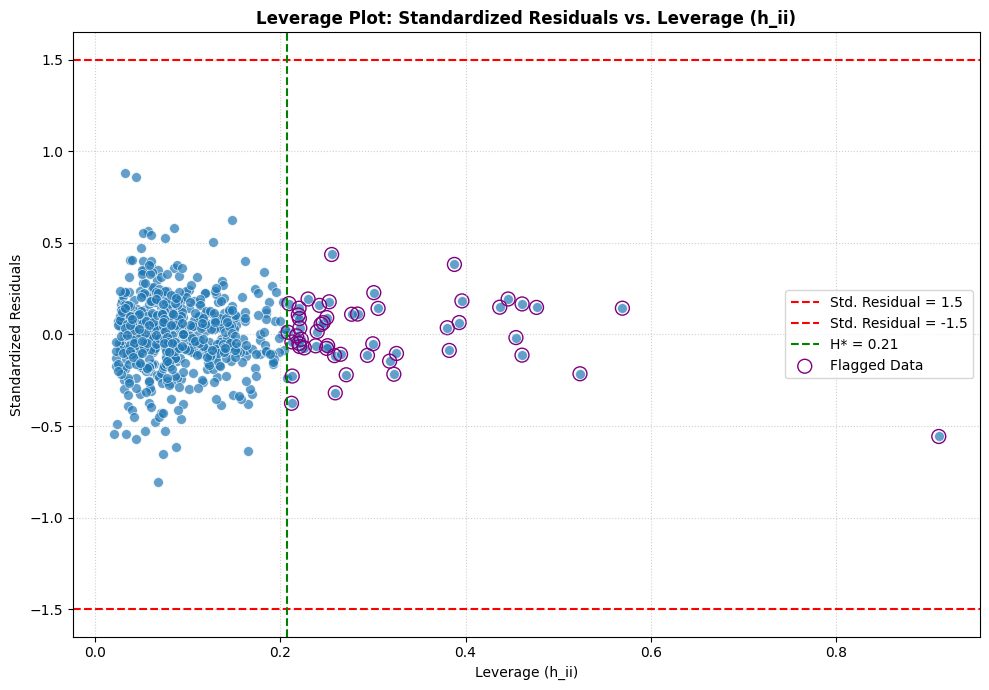

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the threshold for leverage (H_Star1)
# p = number of features in the model (including intercept)
# n = number of samples
p = X_features_np.shape[1] + 1 # +1 for the intercept that was added to X_with_intercept
n = X_features_np.shape[0]
H_Star1 = 2 * p / n

# Identify flagged points based on standardized residuals and leverage
flagged_mask = (np.abs(leverage_df['Standardized_Residuals']) > 2) | (leverage_df['Leverage'] > H_Star1)
flagged_data = leverage_df[flagged_mask]

# Create a figure and a set of subplots
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Leverage', y='Standardized_Residuals', data=leverage_df, s=50, alpha=0.7)

# Add lines for thresholds
plt.axhline(y=1.5, color='r', linestyle='--', label='Std. Residual = 1.5')
plt.axhline(y=-1.5, color='r', linestyle='--', label='Std. Residual = -1.5')
plt.axvline(x=H_Star1, color='g', linestyle='--', label=f'H* = {H_Star1:.2f}')

# Highlight flagged points
plt.scatter(flagged_data['Leverage'], flagged_data['Standardized_Residuals'],
            color='purple', marker='o', s=100, facecolors='none', edgecolors='purple', label='Flagged Data')


plt.title('Leverage Plot: Standardized Residuals vs. Leverage (h_ii)', fontweight = 'bold')
plt.xlabel('Leverage (h_ii)')
plt.ylabel('Standardized Residuals')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('leverage_plot_N2.png', dpi=600, bbox_inches='tight') # Save plot with high resolution
plt.show()

In [38]:
# Get the indices from leverage_df that correspond to the flagged data points
flagged_data_indices = leverage_df[flagged_mask].index

# Drop the flagged data from X_g_filtered
X_g_cleaned = X_g_filtered.drop(index=flagged_data_indices)

# Drop the flagged data from y_g_filtered
y_g_cleaned = y_g_filtered.drop(index=flagged_data_indices)

print("Original filtered shapes (before removing flagged data):")
print(f"X_g_filtered: {X_g_filtered.shape}")
print(f"y_g_filtered: {y_g_filtered.shape}")

print("\nCleaned shapes (after removing flagged data):")
print(f"X_g_cleaned: {X_g_cleaned.shape}")
print(f"y_g_cleaned: {y_g_cleaned.shape}")

Original filtered shapes (before removing flagged data):
X_g_filtered: (674, 69)
y_g_filtered: (674,)

Cleaned shapes (after removing flagged data):
X_g_cleaned: (622, 69)
y_g_cleaned: (622,)


In [39]:
# Cleaned Data Using Leverage Method

final_models = {}           # group_name -> final fitted estimator
final_feature_cols = X_g_cleaned.columns

summary_rows = []

# Using the entire cleaned dataset (no grouping)
X_g = X_g_cleaned.copy()
y_g = y_g_cleaned.copy()
n_g = len(y_g)

overall_group_name = "Overall Dataset (Cleaned)"

print(f"\n========== {overall_group_name} (n spectra={n_g}) ==========")

# Define fixed parameters
fixed_params = {'depth': 6, 'iterations': 400, 'l2_leaf_reg': 5, 'learning_rate': 0.05}

# Instantiate the model with fixed parameters
model_to_use = CatBoostRegressor(
    loss_function='RMSE',
    verbose=False,
    random_seed=42,
    **fixed_params
)

# Manually perform KFold cross-validation to get metrics without grid search
kf = KFold(n_splits=5, shuffle=True, random_state=40)
best_metrics_list = []

print("Running cross-validation with fixed parameters:")
for fold_index, (train_index, test_index) in enumerate(kf.split(X_g), 1):
    X_train_fold, X_test_fold = X_g.iloc[train_index], X_g.iloc[test_index]
    y_train_fold, y_test_fold = y_g.iloc[train_index], y_g.iloc[test_index]

    y_train_fold_1d = y_train_fold.squeeze()
    y_test_fold_1d = y_test_fold.squeeze()

    # Fit model with fixed parameters
    model_to_use.fit(X_train_fold, y_train_fold_1d)
    y_pred = model_to_use.predict(X_test_fold)

    mse = mean_squared_error(y_test_fold_1d, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_fold_1d, y_pred)
    r2 = r2_score(y_test_fold_1d, y_pred)

    best_metrics_list.append({'R²': r2, 'RMSE': rmse, 'MAE': mae})

    print(f"Fold {fold_index}: R²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")
    print("-" * 70)

# Calculate and print mean metrics
metrics_df = pd.DataFrame(best_metrics_list)
metrics_df.index = np.arange(1, len(best_metrics_list) + 1)
metrics_df.index.name = "Fold"

print("\nFinal per-fold metrics (test set):")
print(metrics_df[['R²', 'RMSE', 'MAE']])

mean_row = metrics_df[['R²', 'RMSE', 'MAE']].mean()
print("\nMean metrics across folds:")
print(mean_row)

# Train the final model on the entire dataset with fixed parameters
final_model = CatBoostRegressor(
    loss_function='RMSE',
    verbose=False,
    random_seed=42,
    **fixed_params
)
final_model.fit(X_g, y_g.squeeze())

final_models[overall_group_name] = final_model
print(f"[FINAL MODEL STORED] {overall_group_name} with fixed parameters:", fixed_params)

# Append summary row with mean metrics
summary_rows.append({
    'Group': overall_group_name,
    'Model': "CatBoostRegressor (Fixed Params)",
    'Mean_R2':   mean_row['R²'],
    'Mean_RMSE': mean_row['RMSE'],
    'Mean_MAE':  mean_row['MAE'],
    'n_spectra': n_g
})



========== Overall Dataset (Cleaned) (n spectra=622) ==========
Running cross-validation with fixed parameters:
Fold 1: R²=0.919, RMSE=0.432, MAE=0.313
----------------------------------------------------------------------
Fold 2: R²=0.845, RMSE=0.578, MAE=0.327
----------------------------------------------------------------------
Fold 3: R²=0.771, RMSE=0.536, MAE=0.350
----------------------------------------------------------------------
Fold 4: R²=0.931, RMSE=0.436, MAE=0.275
----------------------------------------------------------------------
Fold 5: R²=0.845, RMSE=0.669, MAE=0.364
----------------------------------------------------------------------

Final per-fold metrics (test set):
            R²      RMSE       MAE
Fold                              
1     0.919387  0.431843  0.313204
2     0.844532  0.578206  0.326715
3     0.770617  0.536232  0.350038
4     0.930605  0.435967  0.275063
5     0.845288  0.669278  0.363713

Mean metrics across folds:
R²      0.862086
RMSE  

In [40]:
summary_df = pd.DataFrame(summary_rows)
#print("\n\n===== SUMMARY OF OVERALL CLEANED MODEL (N2, FTIR-level) =====")
#print(summary_df.sort_values(['Group', 'Mean_R2'], ascending=[True, False]))

In [41]:
# Saving Model After Training

from datetime import datetime

bundle = {
    "final_models": final_models,                 # dict: group -> model
    "X_columns": list(X_g_cleaned.columns.astype(str)), # exact feature order
    "FTIR_MODE": FTIR_MODE,
    "smoothing_params": {
        "STEP": None, # STEP was defined for smoothing, not applicable for PCA
        "window_length": 11,
        "polyorder": 3,
        "deriv_included": True
    },
    "pca_final": pca_final if "pca_final" in globals() and FTIR_MODE=="pca" else None,
    "included_groups": [overall_group_name], # Referencing the overall group name
    "original_ftir_wavenumbers": common_wavelengths # Add common_wavelengths to the bundle
}

fname = f"trained_models_CO2_Leveraged_Ungrouped_No IQR{datetime.now().strftime('_%Y%m%d')}.joblib"
joblib.dump(bundle, fname)
print("Saved:", fname)

Saved: trained_models_CO2_Leveraged_Ungrouped_No IQR_20260420.joblib


In [ ]:
fname = 'trained_models_CO2_Leveraged_Ungrouped_No IQR_20260415.joblib'
loaded_bundle = joblib.load(fname)
print(loaded_bundle)

{'final_models': {'Overall Dataset (Cleaned)': CatBoostRegressor(depth=6, iterations=400, l2_leaf_reg=5, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)}, 'X_columns': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70'], 'FTIR_MODE': 'pca', 'smoothing_params': {'STEP': None, 'window_length': 11, 'polyorder': 3, 'deriv_included': True}, 'pca_final': PCA(n_components=np.int64(71)), 'included_groups': ['Overall Dataset (Cleaned)'], 'original_ftir_wavenumbers': array([ 376.973     ,  382.61909677,  388.26519355,  393.91129032,
        399.5573871 ,  405.20348387,  410.84958065,  416.49567742,
        422.14

In [42]:
# Calculate R2, RMSE, MAE for the original (non-log transformed) data

# Get the final model trained on the cleaned data
final_model = final_models['Overall Dataset (Cleaned)']

# Make predictions on the cleaned features (which are still log-transformed by the model)
predictions_log = final_model.predict(X_g_cleaned)

# Reverse log10 transformation for true values and predictions
y_true_original = 10**y_g_cleaned
y_pred_original = 10**predictions_log

# Calculate metrics on the original scale
r2_original = r2_score(y_true_original, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
mae_original = mean_absolute_error(y_true_original, y_pred_original)

print("\n===== METRICS ON ORIGINAL (NON-LOG) TRANSFORMED DATA =====")
print(f"R² (Original Scale): {r2_original:.3f}")
print(f"RMSE (Original Scale): {rmse_original:.3f}")
print(f"MAE (Original Scale): {mae_original:.3f}")


===== METRICS ON ORIGINAL (NON-LOG) TRANSFORMED DATA =====
R² (Original Scale): 0.890
RMSE (Original Scale): 13.444
MAE (Original Scale): 3.869


In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib # Ensure joblib is imported here

# -------- CONFIG --------
PRED_TRUE_LOG_CSV  = "predictions_and_true_N2_log.csv"
PRED_TRUE_ORIG_CSV = "predictions_and_true_N2_original.csv"

# Load the model bundle
# Assuming 'fname' is available from cell a6fa17cd. If running this cell completely independently,
# you would need to define 'fname' explicitly, e.g., fname = 'trained_models_N2_Leveraged_Ungrouped_20260403_1636.joblib'
loaded_bundle = joblib.load(fname)
final_model = loaded_bundle['final_models']['Overall Dataset (Cleaned)']

# Use the cleaned data for evaluation (assuming X_g_cleaned and y_g_cleaned are already defined globally
# from previous steps where leverage method was applied without IQR)
if 'X_g_cleaned' not in globals() or 'y_g_cleaned' not in globals():
    raise NameError("X_g_cleaned or y_g_cleaned not found. Please ensure preceding data cleaning cells have been executed.")

X_used = X_g_cleaned.copy()
y_true_log = y_g_cleaned.copy().astype(float).squeeze()

# Ensure column names are strings for consistency
X_used.columns = X_used.columns.astype(str)

# Make predictions with the final model
y_pred_log = final_model.predict(X_used)

# ---- Create DataFrame for LOG scale ----
df_log = pd.DataFrame({
    "sample_id": X_used.index,
    "y_true_log": y_true_log,
    "y_pred_log": y_pred_log
})
df_log["difference_log"] = df_log["y_true_log"] - df_log["y_pred_log"]

# ---- Calculate metrics for LOG scale ----
r2_log   = r2_score(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
mae_log  = mean_absolute_error(y_true_log, y_pred_log)

# ---- Transform to ORIGINAL scale ----
y_true_original = np.power(10.0, y_true_log)
y_pred_original = np.power(10.0, y_pred_log)

# ---- Create DataFrame for ORIGINAL scale ----
df_original = pd.DataFrame({
    "sample_id": X_used.index,
    "y_true_original": y_true_original,
    "y_pred_original": y_pred_original
})
df_original["difference_original"] = df_original["y_true_original"] - df_original["y_pred_original"]

# ---- Calculate metrics for ORIGINAL scale ----
r2_original   = r2_score(y_true_original, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
mae_original  = mean_absolute_error(y_true_original, y_pred_original)

# ---- Multiplicative error factor (ALWAYS >= 1) ----
# median(10^|log_pred - log_true|)
med_factor = np.median(np.power(10.0, np.abs(y_pred_log - y_true_log)))

print("\n===== Metrics on Log-Transformed Data ====")
print(f"R²: {r2_log:.3f}")
print(f"RMSE: {rmse_log:.3f}")
print(f"MAE: {mae_log:.3f}")

print("\n===== Metrics on Original Scale Data ====")
print(f"R²: {r2_original:.3f}")
print(f"RMSE: {rmse_original:.3f}")
print(f"MAE: {mae_original:.3f}")
print(f"Median Error Factor: {med_factor:.3f}")

# -------- Save predictions to CSVs --------
df_log.to_csv(PRED_TRUE_LOG_CSV, index=False)
df_original.to_csv(PRED_TRUE_ORIG_CSV, index=False)

print(f"\nSaved log-transformed predictions and true values to -> {PRED_TRUE_LOG_CSV}")
print(f"Saved original scale predictions and true values to -> {PRED_TRUE_ORIG_CSV}")


===== Metrics on Log-Transformed Data ====
R²: 0.996
RMSE: 0.094
MAE: 0.071

===== Metrics on Original Scale Data ====
R²: 0.890
RMSE: 13.444
MAE: 3.869
Median Error Factor: 1.128

Saved log-transformed predictions and true values to -> predictions_and_true_N2_log.csv
Saved original scale predictions and true values to -> predictions_and_true_N2_original.csv


In [ ]:
# ============================================================
# Notebook-ready: Predict CO2 permeability from FTIR (CSV)
# Handles FTIR range mismatch by edge padding
# ============================================================

import numpy as np
import pandas as pd
import joblib
import os
import re

# -----------------------------
# Paths
# -----------------------------
MODEL_PATH = "trained_models_CO2_Leveraged_Ungrouped_No IQR_20260415.joblib"
FTIR_PATH = "FTIR-PEBAx 1657_Ready.csv"

# Manual metadata flags
MANUAL_FEATURES = {
    #"Chemical_Family_Polyamide": 1,
    #"Chemical_Family_Polyether": 1,
    #"Category_Semi-crystalline": 1
}

# -----------------------------
# Helpers
# -----------------------------
def find_column(df, candidates):
    """
    Find a column by partial keyword match.
    """
    for col in df.columns:
        col_low = str(col).lower().strip()
        for cand in candidates:
            if cand.lower() in col_low:
                return col
    return None


def load_ftir_csv(path):
    """
    Robust FTIR CSV reader.
    Assumes first 2 columns are x/y if names are unclear.
    """
    df = pd.read_csv(path)

    # If two columns only, use them directly
    if df.shape[1] == 2:
        df.columns = ["Wavenumber", "Intensity"]
        x_col, y_col = "Wavenumber", "Intensity"
    else:
        x_col = find_column(df, ["wave", "wavenumber", "wavelength", "cm", "wn"])
        y_col = find_column(df, ["int", "abs", "trans", "signal"])

        if x_col is None or y_col is None:
            # Fallback to first two columns
            x_col, y_col = df.columns[:2]

    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    df[y_col] = pd.to_numeric(df[y_col], errors="coerce")
    df = df[[x_col, y_col]].dropna().copy()

    if df.empty:
        raise ValueError("FTIR file has no valid numeric data after cleaning.")

    return df, x_col, y_col


def interpolate_ftir_with_padding(df, x_col, y_col, target_x, warn_threshold=0.10):
    """
    Interpolate FTIR onto training grid.
    If target range exceeds input range, pad with edge values instead of failing.

    warn_threshold:
        fraction of target points outside the input range that triggers a warning.
    """
    df = df[[x_col, y_col]].dropna().sort_values(x_col)
    df = df.groupby(x_col, as_index=False)[y_col].mean()

    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)

    if len(x) < 5:
        raise ValueError("Not enough FTIR points for interpolation.")

    target_x = np.asarray(target_x, dtype=float)

    below = np.sum(target_x < x.min())
    above = np.sum(target_x > x.max())
    outside = below + above
    frac_outside = outside / len(target_x)

    print(f"Input FTIR range   : {x.min():.2f} → {x.max():.2f}")
    print(f"Training grid range: {target_x.min():.2f} → {target_x.max():.2f}")
    print(f"Points outside input range: {outside}/{len(target_x)} ({frac_outside:.1%})")

    if frac_outside > warn_threshold:
        print("Warning: a noticeable part of the training grid is outside the input FTIR range.")
        print("Edge padding will be used for those regions, so prediction may be less reliable.")

    # np.interp uses left/right values for extrapolation when specified
    y_interp = np.interp(target_x, x, y, left=y[0], right=y[-1])

    if np.isnan(y_interp).any():
        raise ValueError("Interpolation produced NaN values.")

    return y_interp


# -----------------------------
# 1) Validate files
# -----------------------------
assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
assert os.path.exists(FTIR_PATH), f"FTIR file not found: {FTIR_PATH}"

# -----------------------------
# 2) Load model bundle
# -----------------------------
bundle = joblib.load(MODEL_PATH)

required_keys = ["final_models", "X_columns", "pca_final", "original_ftir_wavenumbers"]
for k in required_keys:
    assert k in bundle, f"Missing key in saved bundle: {k}"

model = bundle["final_models"]["Overall Dataset (Cleaned)"]
x_columns = [str(c) for c in bundle["X_columns"]]
pca = bundle["pca_final"]
wavenumbers = np.asarray(bundle["original_ftir_wavenumbers"], dtype=float)

# -----------------------------
# 3) Load FTIR CSV
# -----------------------------
ftir, x_col, y_col = load_ftir_csv(FTIR_PATH)
print(f"Using FTIR columns: X = {x_col}, Y = {y_col}")

# -----------------------------
# 4) Interpolate FTIR -> PCA
# -----------------------------
ftir_interp = interpolate_ftir_with_padding(ftir, x_col, y_col, wavenumbers)
ftir_pca = pca.transform(ftir_interp.reshape(1, -1))

# PCA feature names as strings: "0", "1", "2", ...
X_spec = pd.DataFrame(ftir_pca, columns=[str(i) for i in range(ftir_pca.shape[1])])

# -----------------------------
# 5) Build full input row
# -----------------------------
X_new = pd.DataFrame(np.zeros((1, len(x_columns))), columns=x_columns, dtype=float)

# Fill PCA features
for col in X_spec.columns:
    if col in X_new.columns:
        X_new.loc[0, col] = X_spec.loc[0, col]

# Fill manual metadata features
for feat, val in MANUAL_FEATURES.items():
    assert feat in X_new.columns, f"Feature not found in trained input: {feat}"
    X_new.loc[0, feat] = val

# Final checks
assert not X_new.isna().any().any(), "Prepared feature row contains NaNs."
assert list(X_new.columns) == x_columns, "Column order mismatch."

# -----------------------------
# 6) Predict
# -----------------------------
pred_log10 = float(model.predict(X_new)[0])
pred_original = 10 ** pred_log10

print("\nPrediction complete")
print(f"log10 permeability : {pred_log10:.6f}")
print(f"original scale     : {pred_original:.6f}")

# -----------------------------
# 7) Save result
# -----------------------------
result_df = pd.DataFrame({
    "FTIR_File": [FTIR_PATH],
    "Pred_log10": [pred_log10],
    "Pred_original": [pred_original],
    **MANUAL_FEATURES
})

result_df.to_csv("prediction_PEBAx1657.csv", index=False)
print("Saved: prediction_PEBAx1657.csv")

AssertionError: FTIR file not found: FTIR-PEBAx 1657_Ready.csv

In [ ]:

import matplotlib.pyplot as plt

# Get min/max from input FTIR data
input_min_wl = ftir[x_col].min()
input_max_wl = ftir[x_col].max()

# Get min/max from model's expected wavenumbers
model_min_wl = wavenumbers.min()
model_max_wl = wavenumbers.max()

plt.figure(figsize=(12, 6))
plt.plot(ftir[x_col], ftir[y_col], label='Input FTIR Spectrum', color='blue', alpha=0.7)

# Highlight model's expected range
plt.axvspan(model_min_wl, model_max_wl, color='green', alpha=0.08, label='Model Expected Range')

# Highlight input range
plt.axvspan(input_min_wl, input_max_wl, color='blue', alpha=0.08, label='Input FTIR Range')

plt.title('Input FTIR Spectrum vs. Model Expected Wavenumber Range')
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(min(input_min_wl, model_min_wl) - 50, max(input_max_wl, model_max_wl) + 50) # Adjust x-axis limits
plt.tight_layout()
plt.show()

NameError: name 'ftir' is not defined

In [47]:
# ============================================================
# Validate CO2 permeability model with CONSISTENCY CHECKS
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
MODEL_PATH = "trained_models_CO2_Leveraged_Ungrouped_No IQR_20260420.joblib"
FTIR_VALIDATION_PATH = "validation_ftir_spectra.csv"
META_VALIDATION_PATH = "validation_polymer_metadata.csv"
TRAIN_FTIR_PATH = "combined_ftir_data.csv"
TRAIN_PCA_PATH = "pca_transformed_ftir_data.csv"

# -----------------------------
# Helpers
# -----------------------------
def load_validation_spectra(path):
    df = pd.read_csv(path)
    x_col = df.columns[0]
    polymer_cols = list(df.columns[1:])
    return df, x_col, polymer_cols

def interpolate_spectrum_with_padding(x, y, target_x):
    y_interp = np.interp(target_x, x, y, left=y[0], right=y[-1])
    return y_interp

def build_input_row(x_columns, pca_vector):
    X_new = pd.DataFrame(np.zeros((1, len(x_columns))), columns=x_columns, dtype=float)
    pca_cols = [str(i) for i in range(len(pca_vector))]
    for i, col in enumerate(pca_cols):
        if col in X_new.columns:
            X_new.loc[0, col] = pca_vector[i]
    return X_new

# -----------------------------
# 1) Load Model & Check Training Performance
# -----------------------------
bundle = joblib.load(MODEL_PATH)
model = bundle["final_models"]["Overall Dataset (Cleaned)"]
x_columns = [str(c) for c in bundle["X_columns"]]
pca = bundle["pca_final"]
wavenumbers_train = np.asarray(bundle["original_ftir_wavenumbers"], dtype=float)

print(f"Model Loaded. Training features: {len(x_columns)}")

# -----------------------------
# 2) CRITICAL: Consistency check with a training sample
# -----------------------------
if os.path.exists(TRAIN_FTIR_PATH):
    train_raw = pd.read_csv(TRAIN_FTIR_PATH, index_col=0)
    sample_idx = train_raw.index[0]
    sample_spectrum = train_raw.iloc[0].values

    # Manual PCA vs Saved PCA
    pca_manual = pca.transform(sample_spectrum.reshape(1, -1))[0]
    X_check = build_input_row(x_columns, pca_manual)
    pred_check = model.predict(X_check)[0]

    print(f"\n--- CONSISTENCY CHECK (Sample {sample_idx}) ---")
    print(f"Raw Spectrum Mean: {sample_spectrum.mean():.4f}")
    print(f"Predicted Log10: {pred_check:.4f}")

# -----------------------------
# 3) Run Validation
# -----------------------------
ftir_df, x_col, polymer_cols = load_validation_spectra(FTIR_VALIDATION_PATH)
meta_df = pd.read_csv(META_VALIDATION_PATH)
meta_lookup = meta_df.set_index("new_key").to_dict(orient="index")

results = []
x_raw = ftir_df[x_col].to_numpy(dtype=float)

for p_name in polymer_cols:
    p_id = int(p_name)
    if p_id not in meta_lookup: continue

    y_raw = ftir_df[p_name].to_numpy(dtype=float)
    y_interp = interpolate_spectrum_with_padding(x_raw, y_raw, wavenumbers_train)
    pca_vec = pca.transform(y_interp.reshape(1, -1))[0]

    X_val = build_input_row(x_columns, pca_vec)
    pred_log = model.predict(X_val)[0]
    actual_orig = meta_lookup[p_id]["CO2"]

    results.append({
        "id": p_id,
        "actual_log": np.log10(actual_orig),
        "pred_log": pred_log,
        "actual_barrer": actual_orig,
        "pred_barrer": 10**pred_log
    })

res_df = pd.DataFrame(results)
rmse_log = np.sqrt(((res_df['actual_log'] - res_df['pred_log'])**2).mean())
r2_log = 1 - ( ((res_df['actual_log'] - res_df['pred_log'])**2).sum() / ((res_df['actual_log'] - res_df['actual_log'].mean())**2).sum() )

print(f"\n--- VALIDATION RESULTS (N={len(res_df)}) ---")
print(f"R2 (Log Scale): {r2_log:.4f}")
print(f"RMSE (Log Scale): {rmse_log:.4f}")
print("\nTop 5 Results:")
print(res_df.head())


Model Loaded. Training features: 69

--- CONSISTENCY CHECK (Sample 1) ---
Raw Spectrum Mean: 0.0687
Predicted Log10: 0.0799

--- VALIDATION RESULTS (N=169) ---
R2 (Log Scale): -0.0070
RMSE (Log Scale): 1.8668

Top 5 Results:
   id  actual_log  pred_log  actual_barrer  pred_barrer
0   3   -1.000000  0.559428            0.1     3.626001
1   8   -0.301030  0.483414            0.5     3.043783
2  10   -0.301030  0.638996            0.5     4.355080
3  13   -0.301030  0.620456            0.5     4.173078
4  26    1.113943  0.550221           13.0     3.549938


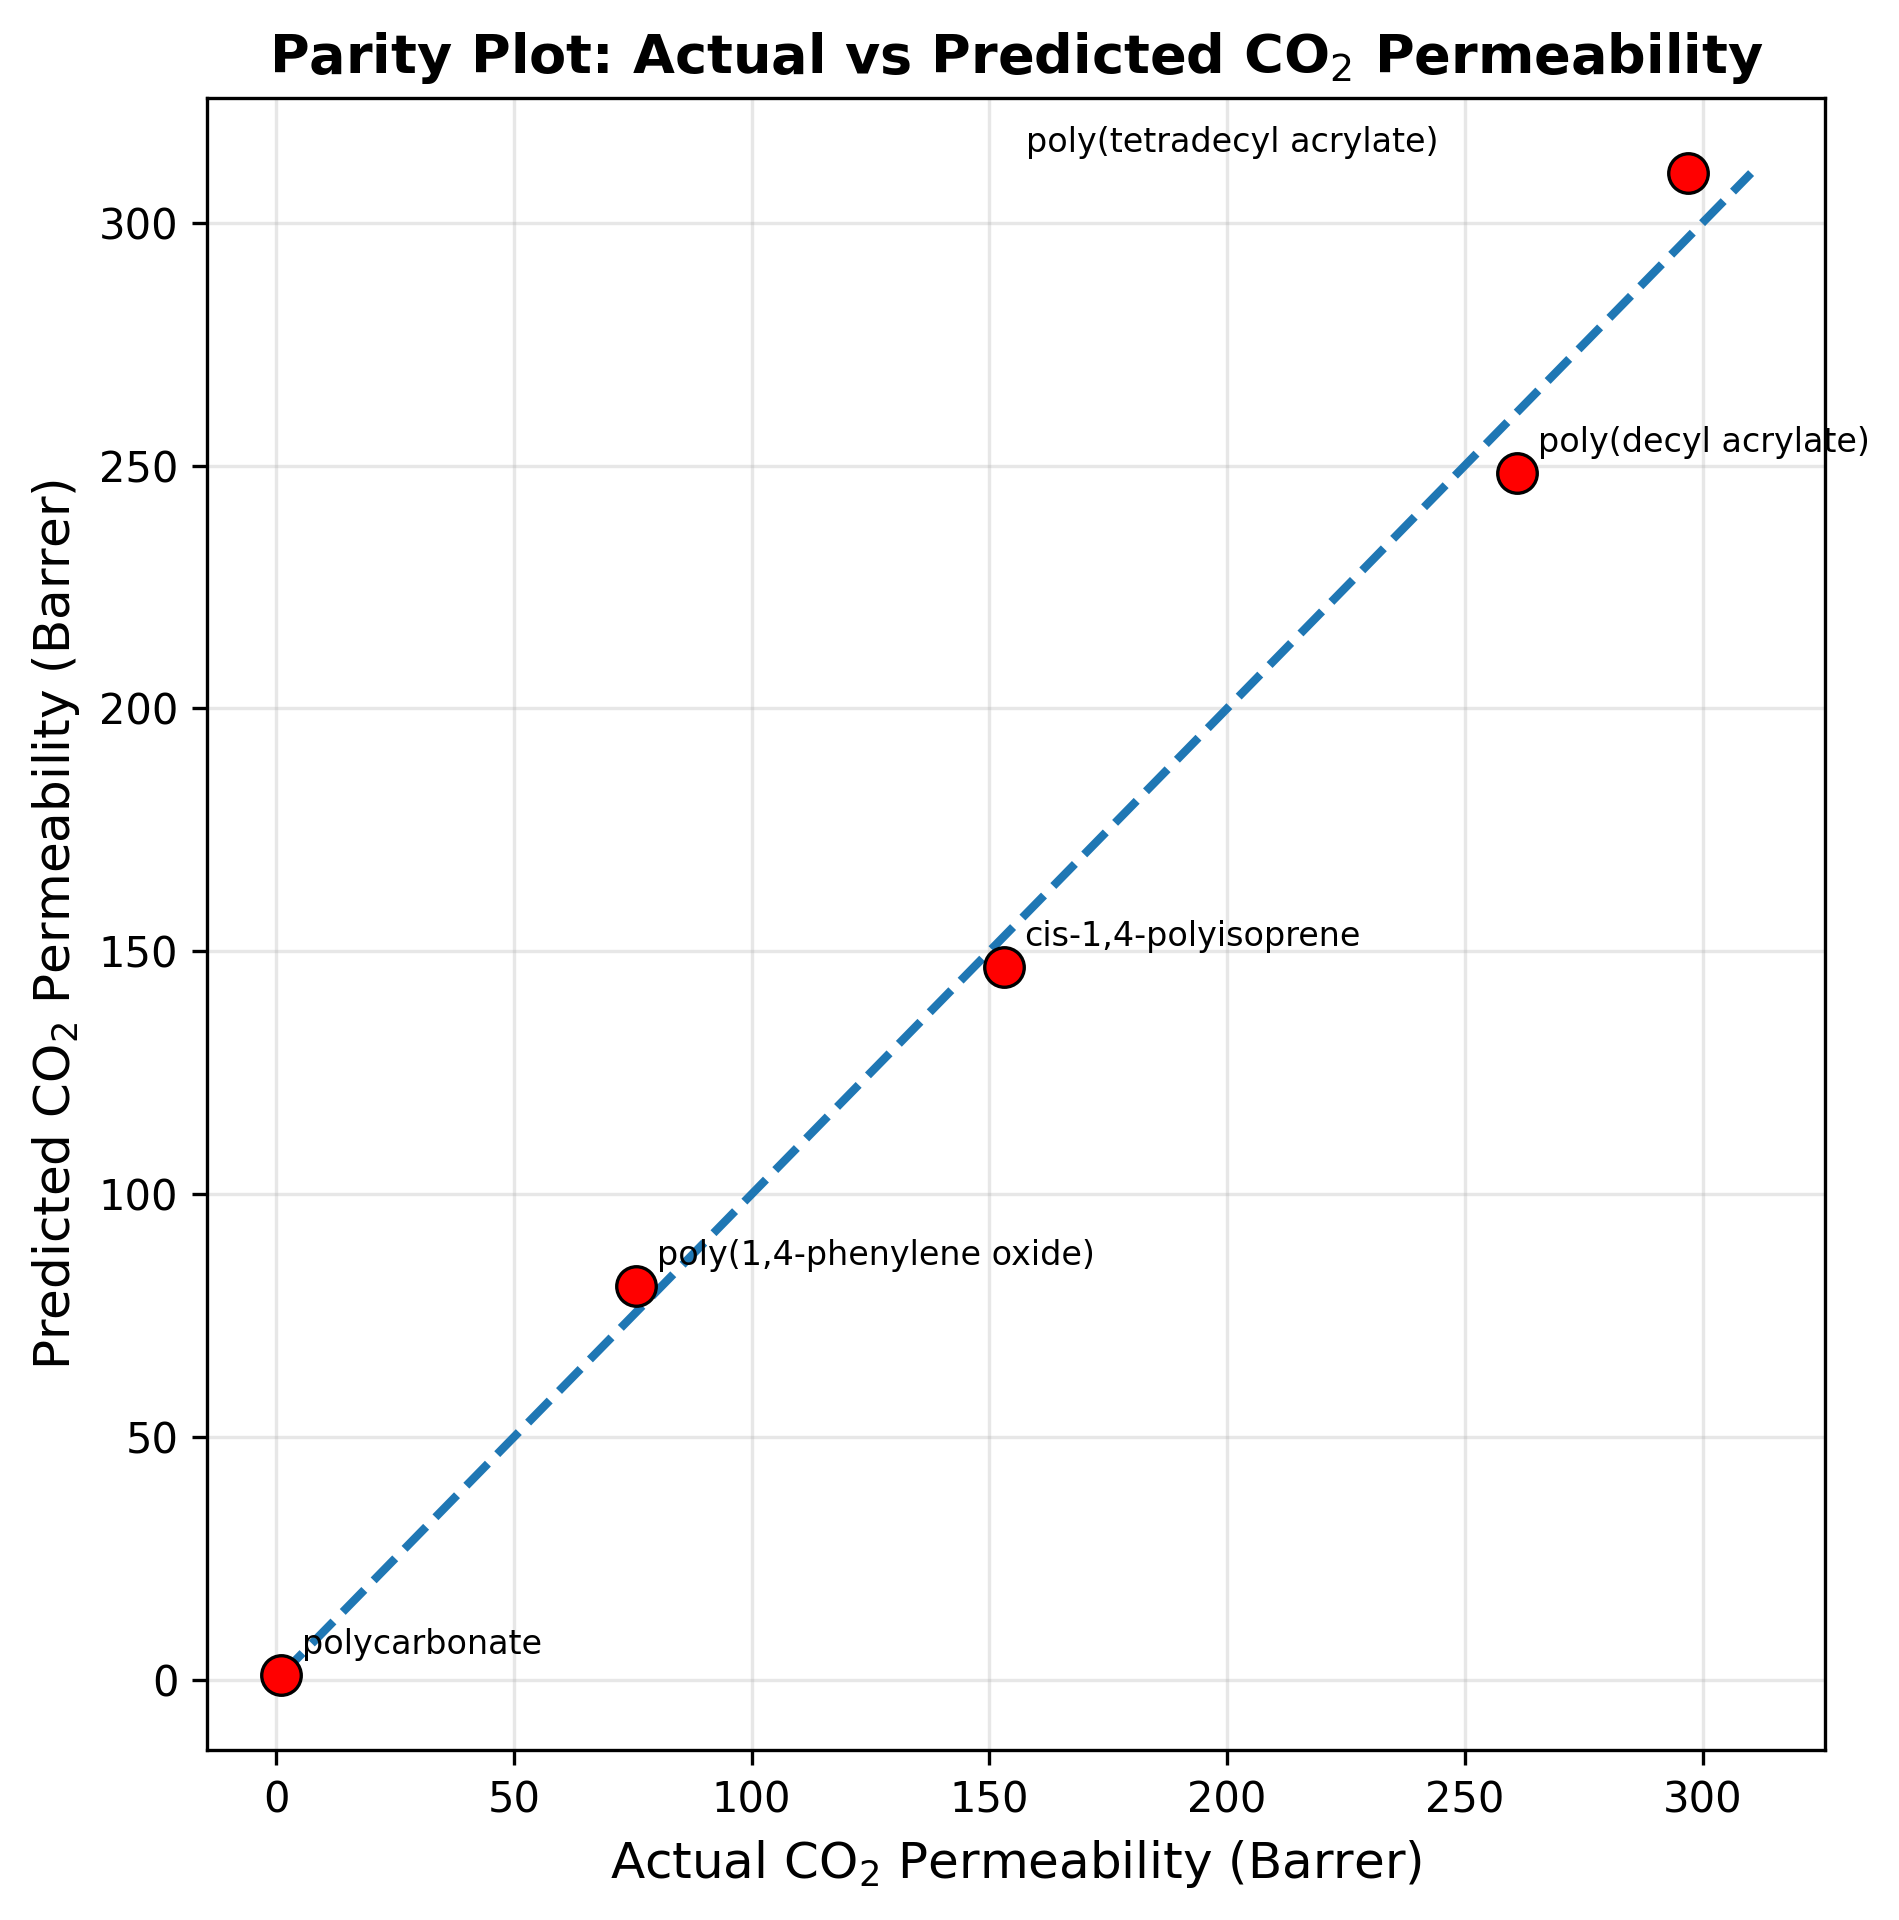

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Replace with your final results
# -----------------------------
actual = np.array([261.00, 297.00, 153.00, 75.70, 1.09])
pred   = np.array([248.50, 310.20, 146.80, 81.10, 1.02])  # <-- replace

labels = [
    "poly(decyl acrylate)",
    "poly(tetradecyl acrylate)",
    "cis-1,4-polyisoprene",
    "poly(1,4-phenylene oxide)",
    "polycarbonate"
]

# -----------------------------
# Create plot
# -----------------------------
plt.figure(figsize=(6.5, 6.5), dpi=300)

# Scatter (RED points)
plt.scatter(
    actual, pred,
    s=90,
    c="red",
    edgecolors="black",
    linewidths=0.8,
    zorder=3
)

# Parity line
min_val = min(actual.min(), pred.min())
max_val = max(actual.max(), pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    zorder=2
)

# Identify top polymer (highest actual value)
top_idx = np.argmax(actual)

# Annotate points
for i in range(len(labels)):
    if i == top_idx:
        # Place label on LEFT for top polymer
        plt.annotate(
            labels[i],
            (actual[i], pred[i]),
            textcoords="offset points",
            xytext=(-60, 5),
            fontsize=8,
            ha="right"
        )
    else:
        # Default placement (right side)
        plt.annotate(
            labels[i],
            (actual[i], pred[i]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

# Labels and title
plt.xlabel("Actual CO$_2$ Permeability (Barrer)", fontsize=12)
plt.ylabel("Predicted CO$_2$ Permeability (Barrer)", fontsize=12)
plt.title(
    "Parity Plot: Actual vs Predicted CO$_2$ Permeability",
    fontsize=13,
    fontweight="bold"
)

# Aesthetics
plt.grid(alpha=0.3)
plt.tight_layout()

# Save high-quality image
plt.savefig(
    "parity_plot_high_quality.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()